In [35]:
import os, sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [36]:
import torch
import pennylane as qml

from torchpenny.module import QLayer, QSubLayer
from torchpenny.lib.qlayer.ansatz import TwoLocalAnsatz
from torchpenny.lib.qlayer.features import ZZfeatureMap

## QLayer with QSubLayer

In [37]:
class QuantumLayer(QLayer):
    def __init__(self, *args, **kwargs):
        super(QuantumLayer, self).__init__(*args, **kwargs)

        # Internal layer 
        self.zzf_input = ZZfeatureMap(self.wires, param_received=True)
        self.two_local1 = TwoLocalAnsatz(self.wires, ['rx', 'rz'], 'cz', "linear")
        self.two_local2 = TwoLocalAnsatz(self.wires, ['rx', 'rz'], 'cz', "circular", except_initial=True)

    def inner_gates(self, x):
        self.zzf_input(x, wires=range(self.wires))
        qml.Barrier(wires=range(self.wires))
        self.two_local1(wires=range(self.wires))
        qml.Barrier(wires=range(self.wires))
        self.two_local2(wires=range(self.wires))
        
    def measurement(self):
        return [qml.expval(qml.PauliZ(i)) for i in range(self.wires)]

In [38]:
qlayer = QuantumLayer(
    wires= 8, 
    q_device = "default.qubit", 
    qnode_kwargs={"diff_method": "backprop"}
    )

In [39]:
qlayer

QuantumLayer[Qnode, wires=8](
  (zzf_input): ZZfeatureMap[15]()
  (two_local1): TwoLocalAnsatz()
  (two_local2): TwoLocalAnsatz()
)

In [40]:
qlayer.input_features

{'zzf_input': torch.Size([15])}

In [41]:
_,  data_i = qlayer.zzf_input.params.shape
data_shape = (4, data_i)
data = torch.rand(data_shape) # Batched data

In [42]:
result = qlayer(data)

In [43]:
result

tensor([[ 0.1283,  0.1341,  0.5567,  0.3491,  0.2164,  0.1802,  0.4403,  0.3584],
        [ 0.0980,  0.4321,  0.2330, -0.0062,  0.1706,  0.2904,  0.4946,  0.1622],
        [ 0.2194,  0.1921,  0.2149,  0.1840,  0.0759,  0.0605,  0.4751,  0.2820],
        [ 0.2275,  0.4403,  0.2322,  0.0886,  0.2851,  0.0435,  0.6657,  0.2576]],
       grad_fn=<ViewBackward0>)

(<Figure size 5000x900 with 1 Axes>, <Axes: >)

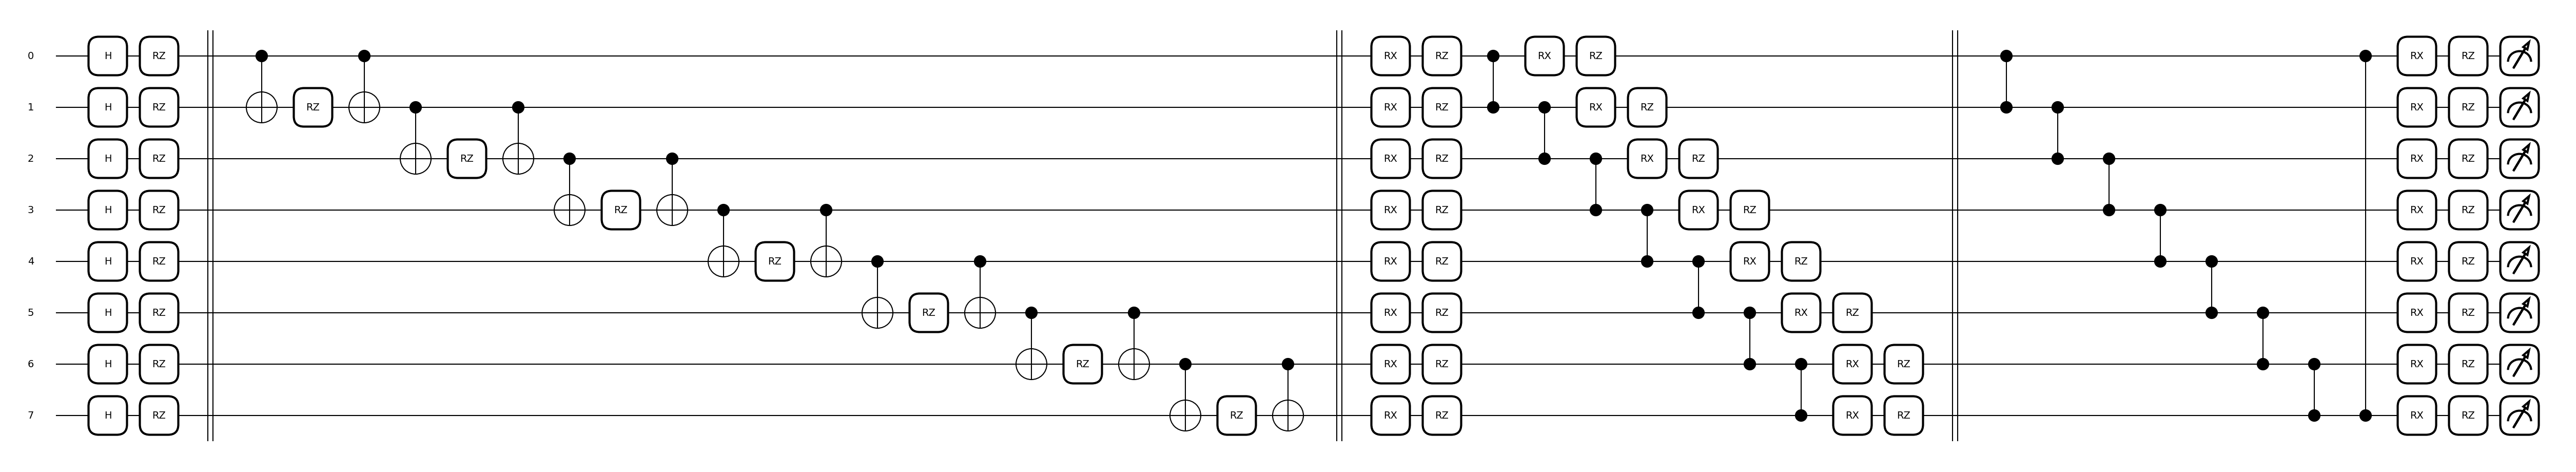

In [44]:
qml.draw_mpl(qlayer.qnode)(data)

## Torch integration

In [108]:
from torch import nn
from torch.optim import Adam
from torch.nn import Module
torch.set_default_dtype(torch.float64)

In [113]:
class ExampleModule(Module):
    def __init__(self):
        super(ExampleModule, self).__init__()
        
        qlayer = QuantumLayer(wires=8, q_device = "default.qubit", qnode_kwargs={"diff_method": "backprop"})
        _, qlayer_input_dim = qlayer.zzf_input.input_dim
        self.layers = nn.Sequential(
            nn.Linear(30, 40), nn.Tanh(),
            nn.Linear(40, qlayer_input_dim), nn.Tanh(),
            qlayer,
            nn.Linear(8, 10)
        )
    def forward(self, x):
        return self.layers(x)

In [114]:
em = ExampleModule()

In [117]:
data = torch.rand((10, 30))
rand_result = torch.rand((10, 10))
initial_result = em(data)

In [118]:
loss_func = nn.MSELoss()

In [119]:
optim = Adam(em.parameters(), lr=0.001)

In [124]:
#his = []
total_epoches = 1000
for i in range(total_epoches):
    optim.zero_grad()
    loss = loss_func(em(data), rand_result)
    his.append(loss.item())
    print(f"Epoch:{i:4}/{total_epoches} \t", loss.item())
    loss.backward()
    optim.step()


Epoch:   0/1000 	 0.0013113680755146525
Epoch:   1/1000 	 0.0013067054874045636
Epoch:   2/1000 	 0.0013020385401022482
Epoch:   3/1000 	 0.0012973669282098602
Epoch:   4/1000 	 0.0012926903472243953
Epoch:   5/1000 	 0.001288008494622375
Epoch:   6/1000 	 0.001283321071047629
Epoch:   7/1000 	 0.0012786277816069808
Epoch:   8/1000 	 0.0012739283372783395
Epoch:   9/1000 	 0.0012692224564350835
Epoch:  10/1000 	 0.0012645098664900046
Epoch:  11/1000 	 0.0012597903056613855
Epoch:  12/1000 	 0.0012550635248625686
Epoch:  13/1000 	 0.0012503292897153733
Epoch:  14/1000 	 0.0012455873826861196
Epoch:  15/1000 	 0.0012408376053414925
Epoch:  16/1000 	 0.0012360797807194268
Epoch:  17/1000 	 0.0012313137558081363
Epoch:  18/1000 	 0.0012265394041238123
Epoch:  19/1000 	 0.0012217566283749127
Epoch:  20/1000 	 0.0012169653631978802
Epoch:  21/1000 	 0.0012121655779459208
Epoch:  22/1000 	 0.0012073572795090399
Epoch:  23/1000 	 0.0012025405151397496
Epoch:  24/1000 	 0.001197715375255308
Epo

In [125]:
from matplotlib import pyplot as plt

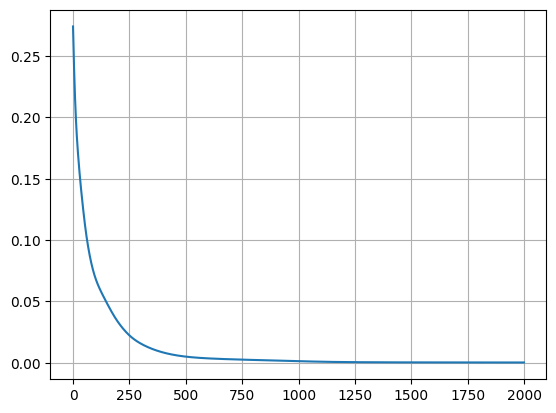

In [126]:
fig, ax= plt.subplots(1,1)
ax.plot(his)
ax.grid()

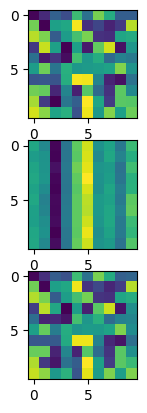

In [127]:
fig, axes= plt.subplots(3,1)
axes[0].imshow(rand_result)
axes[1].imshow(initial_result.detach().numpy())
axes[2].imshow(em(data).detach().numpy())

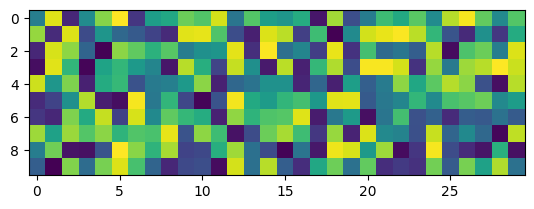

In [128]:
plt.imshow(data)